# Feature Disentanglement Experiment

This notebook follows `feature_disentangle_cell_pseudocode.md`.
It is intentionally an orchestrator: reusable pieces should later move into `Utils/`, `Model/`, or an experiment package.

Execution order:

1. Phase 0: setup, subset construction, perturbation preview/calibration.
2. Phase 1: ResNet and ViT activation/token ranking.
3. Phase 2: Vanilla L1 SAE smoke training.
4. Phase 3: SAE latent validation and perturbation sensitivity.
5. Phase 4: latent intervention with reconstruction/random/matched baselines.

Important interpretation rule: activation maps, attention, and Grad-CAM are only feasibility/localization aids. Causal claims belong only to Phase 4 intervention results.


In [1]:
# Cell 1. Imports

from pathlib import Path
from dataclasses import asdict
import gc
import json
import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm

from Utils.Config import (
    TransformHyperParams,
    DataConfig,
    DatasetSpec,
)
from Utils.Dataset import (
    ImageNetValFlatDataset,
    build_sample_indices_from_targets,
)
from Utils.utils import (
    IMAGENET_R_CLASS_IDS,
    set_seed,
    get_system_info,
    ensure_dir,
    save_json,
    run_perturbation_validation,
    cal_accuracy,
)
from Utils.metric import (
    js_divergence,
)
from Utils.feature_disentangle import (
    build_loader as build_feature_loader,
    make_timm_model_spec,
    safe_linear_cka,
    to_display_image,
    build_visual_transforms,
    save_perturbation_preview,
    run_model_level_calibration,
    get_resnet_layers_by_name,
    run_resnet_streaming_phase1,
    select_top_resnet_channels,
    required_resnet_visualization_inputs,
    resnet_outputs_cover_visualization,
    extract_resnet_outputs_for_visualization,
    run_vit_streaming_phase1,
    select_top_vit_blocks,
    required_vit_visualization_inputs,
    vit_outputs_cover_visualization,
    vit_patch_delta_maps,
    vit_cached_image_index,
    extract_vit_outputs_for_visualization,
    extract_vit_outputs_for_cache,
    plot_resnet_channel_comparison,
    plot_vit_patch_delta,
    plot_vit_attention_activation_summary,
    load_json_if_exists,
    resnet_cached_image_index,
)




In [2]:
# Cell 2. Experiment Settings

# 실행/재현성
SEED = 42
RUN_SYSTEM_INFO = True
DTYPE_FOR_CACHE = torch.float16
USE_PRETRAINED_WEIGHTS = True

# pretrained model 선택
RESNET_TIMM_MODEL_NAME = 'resnet50'
RESNET_PRETRAINED_WEIGHT_LABEL = 'in1k'
VIT_TIMM_MODEL_NAME = 'vit_base_patch16_224.augreg_in1k'
VIT_PRETRAINED_WEIGHT_LABEL = 'augreg_in1k'

# 경로
DATA_ROOT = 'Data'
IMAGENET_R_ROOT = 'Data/imagenet-r'
CACHE_ROOT = 'Cache'
OUTPUT_ROOT = 'outputs/feature_disentangle'

# perturbation 구성
PERTURBATIONS = ['original', 'grayscale', 'bilateral', 'patchshuffle', 'patchrotation', 'localwarp']
PERTURBATION_TO_CUE = {'original': 'none', 'grayscale': 'color', 'bilateral': 'texture', 'patchshuffle': 'shape', 'patchrotation': 'shape', 'localwarp': 'shape'}

# transform 기본값
TRANSFORM_KWARGS = dict(p=1.0, prefix='resizecrop', resize_size=256, gray_alpha=1.0, bilateral_d=11, sigma_color=170, sigma_space=75, grid_size=7, alpha_localwarp=35, sigma_localwarp=3.5)

# dataset / dataloader
SMOKE_MODE = False
SMOKE_N = 128
MAIN_N = 4096
DATA_BATCH_SIZE = 256 if torch.cuda.is_available() else 16
NUM_WORKERS = 0  # WSL에서 worker 복제 RAM 사용을 피하기 위해 기본 0
DATA_SHUFFLE = False
DATA_PIN_MEMORY = None  # None이면 CUDA 여부에 맞춤

# Phase 0 preview / calibration
PREVIEW_K = 4
RUN_PREVIEW = True
RUN_PERTURBATION_VALIDATION = False
VALIDATION_MAX_SAMPLES = None  # None이면 smoke subset 크기 사용
RUN_MODEL_LEVEL_CALIBRATION = False
MODEL_CALIBRATION_MAX_BATCHES = None

# Phase 1 ResNet ranking
RUN_RESNET_PHASE1 = True
RESNET_MAX_BATCHES = None
RESNET_TOP_K_CHANNELS = 20
RESNET_TARGET_LAYER_NAMES = ['layer4']  # conv1/layer1은 RAM 사용량이 큼

# Phase 1 ViT ranking
RUN_VIT_PHASE1 = True
VIT_CANDIDATE_BLOCKS = [6, 9, 11]  # 필요한 block만 늘려서 사용
VIT_FINAL_BLOCK_INDEX = 11  # ViT-B/16은 12 blocks, zero-indexed 마지막 block
VIT_FINAL_BLOCK_TOKEN_SCOPE = 'cls'  # 'cls'면 마지막 block SAE는 CLS token만 학습
VIT_MAX_BATCHES = None
VIT_TOP_K_BLOCKS = 5

# Phase 1 memory control
PHASE1_KEEP_OUTPUTS_IN_MEMORY = False  # True면 activation/token 전체를 RAM에 보관하므로 OOM 위험
PHASE1_STREAMING_RANKING = True  # True면 batch 단위로 metric만 누적

# Phase 1 visualization
RUN_RESNET_VIS = True
RUN_VIT_VIS = True
VIS_IMAGE_POSITIONS = [0, 1, 2]

# Phase 2 SAE training
SAE_TRAIN_VERBOSE = 100
RUN_SAE_TRAINING = True
SAE_SOURCE_TYPE = 'vit'  # 'vit' 또는 'resnet'
SAE_TARGET_BLOCK = 9
SAE_TARGET_LAYER = 'layer4'
SAE_USE_STD = True
SAE_MAX_TRAIN_TOKENS = 50_000
SAE_MAX_VAL_TOKENS = 10_000
SAE_BATCH_SIZE = 2048
SAE_EPOCHS = 500
SAE_NORMALIZE_DECODER = True
SAE_TARGET_L0_RANGE = (256, 1024)  # ViT-B/16의 block 9는 16~1968, ResNet의 layer4는 16~2048
SAE_MIN_R2 = 0.80
SAE_RUN_PREFIX = 'sparse_suml1'
SAE_SWEEP = [
    {'expansion_factor': 4, 'lambda_l1': 1e-3, 'lr': 3e-4},
    {'expansion_factor': 4, 'lambda_l1': 3e-3, 'lr': 3e-4},
    {'expansion_factor': 4, 'lambda_l1': 1e-2, 'lr': 3e-4},
    {'expansion_factor': 4, 'lambda_l1': 5e-2, 'lr': 3e-4},
    {'expansion_factor': 8, 'lambda_l1': 1e-3, 'lr': 3e-4},
    {'expansion_factor': 8, 'lambda_l1': 3e-3, 'lr': 3e-4},
    {'expansion_factor': 8, 'lambda_l1': 5e-2, 'lr': 3e-4},
    {'expansion_factor': 8, 'lambda_l1': 1e-2, 'lr': 3e-4},
]

# Phase 3 SAE validation
RUN_SAE_VALIDATION = True
SELECTED_SAE_RUN_DIR = None  # None이면 Phase 2 선택 run 사용
LATENT_TOP_K = 1e6
LATENT_ACTIVE_THRESHOLD = 1e-4
HIGH_FREQ_THRESHOLD = 0.6
DEAD_FREQ_THRESHOLD = 1e-6

# Phase 4 intervention
RUN_INTERVENTION = True
INTERVENTION_ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
INTERVENTION_MAX_BATCHES = None
RANDOM_BASELINE_REPEATS = 3

set_seed(SEED)

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
data_root = Path(DATA_ROOT)
imagenet_r_root = Path(IMAGENET_R_ROOT)
cache_root = Path(CACHE_ROOT)
output_root = Path(OUTPUT_ROOT)

phase0_dir = output_root / 'phase0_perturbation_calibration'
phase1_dir = output_root / 'phase1_activation_maps'
phase2_dir = output_root / 'phase2_sae'
phase3_dir = output_root / 'phase3_latent_validation'
phase4_dir = output_root / 'phase4_intervention'

for d in [output_root, phase0_dir, phase1_dir, phase2_dir, phase3_dir, phase4_dir]:
    ensure_dir(d)

perturbations = list(PERTURBATIONS)
perturbation_to_cue = dict(PERTURBATION_TO_CUE)
shape_perturbations = [p for p, cue in perturbation_to_cue.items() if cue == 'shape']
transform_hparams = TransformHyperParams(**TRANSFORM_KWARGS)

run_config = {
    'seed': SEED,
    'device': str(DEVICE),
    'dtype_for_cache': str(DTYPE_FOR_CACHE),
    'use_pretrained_weights': USE_PRETRAINED_WEIGHTS,
    'models': {'resnet': RESNET_TIMM_MODEL_NAME, 'vit': VIT_TIMM_MODEL_NAME},
    'paths': {'data_root': str(data_root), 'imagenet_r_root': str(imagenet_r_root), 'cache_root': str(cache_root), 'output_root': str(output_root)},
    'perturbations': perturbations,
    'perturbation_to_cue': perturbation_to_cue,
    'transform_hparams': asdict(transform_hparams),
}
save_json(run_config, output_root / 'run_config.json')

if RUN_SYSTEM_INFO:
    get_system_info()

print(f'Using device: {DEVICE}')
print(f'Outputs: {output_root.resolve()}')




[Seed set to 42 | deterministic=True]
===== System Info =====
OS: Linux 5.15.167.4-microsoft-standard-WSL2
Python Version: 3.11.14
CPU: x86_64
RAM: 27.41 GB

===== PyTorch Info =====
PyTorch Version: 2.4.0+cu118
CUDA Available: True
CUDA Version (PyTorch): 11.8
GPU Count: 1
GPU 0: NVIDIA GeForce RTX 4070, 11.99 GB VRAM
Using device: cuda:0
Outputs: /home/user/projects/Feature-Reliance/outputs/feature_disentangle


## Phase 0. Dataset And Perturbation Calibration

The subset is ImageNet validation filtered to ImageNet-R aligned 200 classes. The same selected image indices are reused across clean, perturbed, model, and intervention comparisons.


In [3]:
# Cell 3. Dataset Subset Builder


base_ds = ImageNetValFlatDataset(root=str(data_root), transform=None)
imagenet_200_indices = build_sample_indices_from_targets(
    targets=base_ds.targets,
    class_ids=IMAGENET_R_CLASS_IDS,
)
print(f'ImageNet-R aligned ImageNet val images: {len(imagenet_200_indices):,}')

if SMOKE_MODE:
    rng = np.random.default_rng(SEED)
    n = min(SMOKE_N, len(imagenet_200_indices))
    selected_indices = sorted(int(i) for i in rng.choice(imagenet_200_indices, size=n, replace=False))
elif MAIN_N is not None:
    rng = np.random.default_rng(SEED)
    n = min(MAIN_N, len(imagenet_200_indices))
    selected_indices = sorted(int(i) for i in rng.choice(imagenet_200_indices, size=n, replace=False))
else:
    selected_indices = [int(i) for i in imagenet_200_indices]

imagenet_200_spec = DatasetSpec(
    name='imagenet_200',
    dataset_type='imagenet_val_subset',
    root=str(data_root),
    split='val',
    num_classes=200,
    class_map_name='imagenet_r_subset_map',
    sample_indices=selected_indices,
    labels_map=[int(x) for x in IMAGENET_R_CLASS_IDS],
    id_dataset_name='imagenet_200',
)

imagenet_r_spec = DatasetSpec(
    name='imagenet_r',
    dataset_type='imagenet_r',
    root=str(imagenet_r_root),
    split='val',
    num_classes=200,
    domain_type='natural_ood',
    shift_type='style',
    class_map_name='imagenet_r_subset_map',
    eval_protocol_name='imagenet_r_eval',
    id_dataset_name='imagenet_200',
)

data_config = DataConfig(
    batch_size=DATA_BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available() if DATA_PIN_MEMORY is None else DATA_PIN_MEMORY,
    shuffle=DATA_SHUFFLE,
    datasets=[imagenet_200_spec, imagenet_r_spec],
)

save_json(
    {
        'smoke_mode': SMOKE_MODE,
        'smoke_n': SMOKE_N,
        'main_n': MAIN_N,
        'num_selected': len(selected_indices),
        'selected_indices': selected_indices,
    },
    phase0_dir / 'selected_indices.json',
)


def build_loader(dataset_spec, perturbation, model_spec, normalize=True, batch_size=None, shuffle=False):
    return build_feature_loader(
        dataset_spec,
        perturbation=perturbation,
        model_spec=model_spec,
        transform_hparams=transform_hparams,
        data_config=data_config,
        normalize=normalize,
        batch_size=batch_size,
        shuffle=shuffle,
    )


def make_resnet50_spec(pretrained=USE_PRETRAINED_WEIGHTS):
    return make_timm_model_spec(
        timm,
        timm_model_name=RESNET_TIMM_MODEL_NAME,
        notebook_model_name='resnet50',
        pretrained_weight_label=RESNET_PRETRAINED_WEIGHT_LABEL,
        pretrained=pretrained,
    )


def make_vit_b16_spec(pretrained=USE_PRETRAINED_WEIGHTS):
    return make_timm_model_spec(
        timm,
        timm_model_name=VIT_TIMM_MODEL_NAME,
        notebook_model_name='vit-b',
        pretrained_weight_label=VIT_PRETRAINED_WEIGHT_LABEL,
        pretrained=pretrained,
    )

print(f'Selected subset size: {len(selected_indices):,}')
print(f'Data batch size: {data_config.batch_size}')




ImageNet-R aligned ImageNet val images: 10,000
Selected subset size: 4,096
Data batch size: 256


In [4]:
# Shared metric helpers for Phase 1+

print('Shared Phase 1 metric helpers imported from Utils.feature_disentangle.')


Shared Phase 1 metric helpers imported from Utils.feature_disentangle.


In [5]:
# Cell 4. Perturbation Preview and Validation

validation_max_samples = VALIDATION_MAX_SAMPLES if VALIDATION_MAX_SAMPLES is not None else (min(SMOKE_N, len(selected_indices)) if SMOKE_MODE else None)

preview_paths = []
if RUN_PREVIEW:
    visual_transforms = build_visual_transforms(perturbations, transform_hparams)
    for sample_global_idx in selected_indices[:PREVIEW_K]:
        preview_paths.append(save_perturbation_preview(
            base_ds,
            sample_global_idx,
            perturbations,
            perturbation_to_cue,
            visual_transforms,
            phase0_dir,
        ))
    print('Saved preview images:')
    for path in preview_paths:
        print(f'  {path}')

validation_df = pd.DataFrame()
if RUN_PERTURBATION_VALIDATION:
    validation_result = run_perturbation_validation(
        transform_hparams=transform_hparams,
        perturbations=perturbations,
        max_samples=validation_max_samples,
        verbose_image=False,
        max_workers=max(1, min(len(perturbations) - 1, NUM_WORKERS)),
    )
    rows = []
    for perturbation, record in validation_result.results.items():
        rows.append({
            'perturbation': perturbation,
            'cue': perturbation_to_cue.get(perturbation, 'unknown'),
            'config_hash': record.config_hash,
            **record.metrics,
        })
    validation_df = pd.DataFrame(rows).sort_values(['cue', 'perturbation'])
    validation_df.to_csv(phase0_dir / 'perturbation_input_metrics.csv', index=False)
    display(validation_df)
else:
    print('RUN_PERTURBATION_VALIDATION=False, skipped input-level calibration run.')

if RUN_MODEL_LEVEL_CALIBRATION:
    calib_specs = [make_resnet50_spec(), make_vit_b16_spec()]
    model_calibration_df = run_model_level_calibration(
        calib_specs,
        imagenet_200_spec,
        perturbations,
        perturbation_to_cue,
        build_loader,
        phase0_dir,
        DEVICE,
        max_batches=MODEL_CALIBRATION_MAX_BATCHES,
    )
    display(model_calibration_df)
else:
    print('RUN_MODEL_LEVEL_CALIBRATION=False, skipped model-level calibration run.')




Saved preview images:
  outputs/feature_disentangle/phase0_perturbation_calibration/perturbation_preview_22.png
  outputs/feature_disentangle/phase0_perturbation_calibration/perturbation_preview_24.png
  outputs/feature_disentangle/phase0_perturbation_calibration/perturbation_preview_48.png
  outputs/feature_disentangle/phase0_perturbation_calibration/perturbation_preview_51.png
RUN_PERTURBATION_VALIDATION=False, skipped input-level calibration run.
RUN_MODEL_LEVEL_CALIBRATION=False, skipped model-level calibration run.


## Phase 1. Activation And Token Ranking

Phase 1 only checks whether perturbations produce stable, localized representation changes. Do not treat these rankings as causal evidence.


In [6]:
# Cell 5. ResNet Activation Extraction and Ranking

resnet_outputs = globals().get('resnet_outputs', {})
resnet_layer_df = globals().get('resnet_layer_df', pd.DataFrame())
resnet_channel_df = globals().get('resnet_channel_df', pd.DataFrame())
resnet_top_channels = globals().get('resnet_top_channels', {})

if RUN_RESNET_PHASE1:
    if PHASE1_KEEP_OUTPUTS_IN_MEMORY:
        print('[WARN] PHASE1_KEEP_OUTPUTS_IN_MEMORY=True can use a lot of RAM. Streaming ranking is still used here.')

    resnet_spec = make_resnet50_spec()
    resnet = resnet_spec.model
    resnet_layer_df, resnet_channel_df = run_resnet_streaming_phase1(
        resnet,
        resnet_spec,
        imagenet_200_spec,
        perturbations,
        RESNET_TARGET_LAYER_NAMES,
        perturbation_to_cue,
        shape_perturbations,
        build_loader,
        DEVICE,
        max_batches=RESNET_MAX_BATCHES,
    )

    resnet_layer_df.to_csv(phase1_dir / 'phase1_resnet_layer_ranking.csv', index=False)
    resnet_channel_df.to_csv(phase1_dir / 'phase1_resnet_channel_ranking.csv', index=False)
    resnet_top_channels = select_top_resnet_channels(resnet_channel_df, top_k=RESNET_TOP_K_CHANNELS)
    save_json(resnet_top_channels, phase1_dir / 'phase1_resnet_top_channels.json')

    if RUN_RESNET_VIS:
        resnet_vis_requirements = required_resnet_visualization_inputs(
            resnet_top_channels,
            VIS_IMAGE_POSITIONS,
            perturbation_to_cue,
            RESNET_TARGET_LAYER_NAMES,
        )
        if not resnet_outputs_cover_visualization(resnet_outputs, resnet_vis_requirements):
            print(
                'Caching small ResNet outputs for visualization: '
                f"images={resnet_vis_requirements['image_positions']}, "
                f"layers={resnet_vis_requirements['layers']}, "
                f"perturbations={resnet_vis_requirements['perturbations']}"
            )
            resnet_outputs = extract_resnet_outputs_for_visualization(
                resnet,
                resnet_spec,
                imagenet_200_spec,
                resnet_vis_requirements['perturbations'],
                resnet_vis_requirements['layers'],
                resnet_vis_requirements['image_positions'],
                selected_indices,
                build_loader,
                data_config,
                DTYPE_FOR_CACHE,
                DEVICE,
            )

    display(resnet_layer_df)
    display(resnet_channel_df.head())

    resnet.cpu()
    del resnet
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print('RUN_RESNET_PHASE1=False, skipped ResNet activation extraction.')




ResNet streaming original vs grayscale:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet streaming original vs bilateral:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet streaming original vs patchshuffle:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet streaming original vs patchrotation:   0%|          | 0/16 [00:00<?, ?it/s]

ResNet streaming original vs localwarp:   0%|          | 0/16 [00:00<?, ?it/s]

...

ResNet vis cache grayscale:   0%|          | 0/1 [00:00<?, ?it/s]

ResNet vis cache bilateral:   0%|          | 0/1 [00:00<?, ?it/s]

ResNet vis cache patchshuffle:   0%|          | 0/1 [00:00<?, ?it/s]

,model,layer,perturbation,cue,n_batches,cka,cosine_distance,l2_distance,delta_mean
0,resnet50,layer4,grayscale,color,16,0.557266,0.286987,72.647018,0.039934
4,resnet50,layer4,localwarp,shape,16,0.074427,0.825706,124.655721,0.081362
3,resnet50,layer4,patchrotation,shape,16,0.177233,0.642241,120.400972,0.074489
2,resnet50,layer4,patchshuffle,shape,16,0.088033,0.825265,139.807288,0.084625
1,resnet50,layer4,bilateral,texture,16,0.356917,0.447763,92.545292,0.053226


,model,layer,channel,sensitivity_grayscale,sensitivity_bilateral,sensitivity_patchshuffle,sensitivity_patchrotation,sensitivity_localwarp,color_specificity,texture_specificity,shape_specificity
0,resnet50,layer4,0,0.243887,0.290871,0.482075,0.526893,0.670000,-0.248573,-0.189843,0.292277
1,resnet50,layer4,1,0.237751,0.281475,0.364155,0.357338,0.363272,-0.103809,-0.049154,0.101975
2,resnet50,layer4,2,0.187094,0.223953,0.335563,0.341136,0.307892,-0.115042,-0.068968,0.122673
3,resnet50,layer4,3,0.189225,0.319232,0.305974,0.315818,0.413046,-0.149293,0.013217,0.090717
4,resnet50,layer4,4,0.218154,0.282715,0.359913,0.388363,0.397025,-0.138850,-0.058149,0.131332


In [7]:
# Cell 6. ViT Patch Token Extraction and Ranking

vit_outputs = globals().get('vit_outputs', {})
vit_block_df = globals().get('vit_block_df', pd.DataFrame())
vit_top_blocks = globals().get('vit_top_blocks', {})

if RUN_VIT_PHASE1:
    if PHASE1_KEEP_OUTPUTS_IN_MEMORY:
        print('[WARN] PHASE1_KEEP_OUTPUTS_IN_MEMORY=True can use a lot of RAM. Streaming ranking is still used here.')

    vit_spec = make_vit_b16_spec()
    vit = vit_spec.model
    vit_block_df = run_vit_streaming_phase1(
        vit,
        vit_spec,
        imagenet_200_spec,
        perturbations,
        VIT_CANDIDATE_BLOCKS,
        perturbation_to_cue,
        build_loader,
        DEVICE,
        max_batches=VIT_MAX_BATCHES,
    )
    vit_block_df.to_csv(phase1_dir / 'phase1_vit_block_ranking.csv', index=False)
    vit_top_blocks = select_top_vit_blocks(vit_block_df, top_k=VIT_TOP_K_BLOCKS)
    save_json(vit_top_blocks, phase1_dir / 'phase1_vit_top_blocks.json')

    display(vit_block_df)
    print(vit_top_blocks)

    vit.cpu()
    del vit
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print('RUN_VIT_PHASE1=False, skipped ViT token extraction.')




ViT streaming original vs grayscale:   0%|          | 0/16 [00:00<?, ?it/s]

ViT streaming original vs bilateral:   0%|          | 0/16 [00:00<?, ?it/s]

ViT streaming original vs patchshuffle:   0%|          | 0/16 [00:00<?, ?it/s]

ViT streaming original vs patchrotation:   0%|          | 0/16 [00:00<?, ?it/s]

ViT streaming original vs localwarp:   0%|          | 0/16 [00:00<?, ?it/s]

,model,block,perturbation,cue,block_score,n_batches,cka,cosine_distance,l2_distance
2,vit-b,11,grayscale,color,97.696389,16,0.795624,0.272368,97.696389
1,vit-b,9,grayscale,color,67.137556,16,0.898939,0.274261,67.137556
0,vit-b,6,grayscale,color,37.473843,16,0.938513,0.195975,37.473843
14,vit-b,11,localwarp,shape,133.738590,16,0.640532,0.485705,133.738590
13,vit-b,9,localwarp,shape,90.339972,16,0.816635,0.451717,90.339972
12,vit-b,6,localwarp,shape,52.300058,16,0.872453,0.325216,52.300058
11,vit-b,11,patchrotation,shape,121.928602,16,0.664560,0.385129,121.928602
10,vit-b,9,patchrotation,shape,92.471141,16,0.784067,0.437757,92.471141
9,vit-b,6,patchrotation,shape,58.409636,16,0.834606,0.395600,58.409636
8,vit-b,11,patchshuffle,shape,155.288737,16,0.463149,0.550889,155.288737


{'color': [{'block': 11, 'mean_delta': 97.69638919830322, 'mean_cka': 0.795623779296875, 'rank_score': 96.90076541900635}, {'block': 9, 'mean_delta': 67.1375560760498, 'mean_cka': 0.8989389203488827, 'rank_score': 66.23861715570092}, {'block': 6, 'mean_delta': 37.47384333610535, 'mean_cka': 0.9385126456618309, 'rank_score': 36.535330690443516}], 'texture': [{'block': 11, 'mean_delta': 102.72117567062378, 'mean_cka': 0.760519590228796, 'rank_score': 101.96065608039498}, {'block': 9, 'mean_delta': 74.67757177352905, 'mean_cka': 0.8555396646261215, 'rank_score': 73.82203210890293}, {'block': 6, 'mean_delta': 43.75193381309509, 'mean_cka': 0.8951891511678696, 'rank_score': 42.85674466192722}], 'shape': [{'block': 11, 'mean_delta': 136.98530991872153, 'mean_cka': 0.5894134764870008, 'rank_score': 136.39589644223452}, {'block': 9, 'mean_delta': 102.81268707911174, 'mean_cka': 0.7268047258257866, 'rank_score': 102.08588235328595}, {'block': 6, 'mean_delta': 64.53310656547546, 'mean_cka': 0.78

,cue,block,mean_delta,mean_cka,mean_cosine_distance,mean_l2_distance,n_perturbations,rank_score
2,color,11,97.696389,0.795624,0.272368,97.696389,1,96.900765
1,color,9,67.137556,0.898939,0.274261,67.137556,1,66.238617
0,color,6,37.473843,0.938513,0.195975,37.473843,1,36.535331
5,shape,11,136.985310,0.589413,0.473908,136.985310,3,136.395896
4,shape,9,102.812687,0.726805,0.525265,102.812687,3,102.085882
3,shape,6,64.533107,0.786339,0.464417,64.533107,3,63.746767
8,texture,11,102.721176,0.760520,0.282058,102.721176,1,101.960656
7,texture,9,74.677572,0.855540,0.296866,74.677572,1,73.822032
6,texture,6,43.751934,0.895189,0.229348,43.751934,1,42.856745


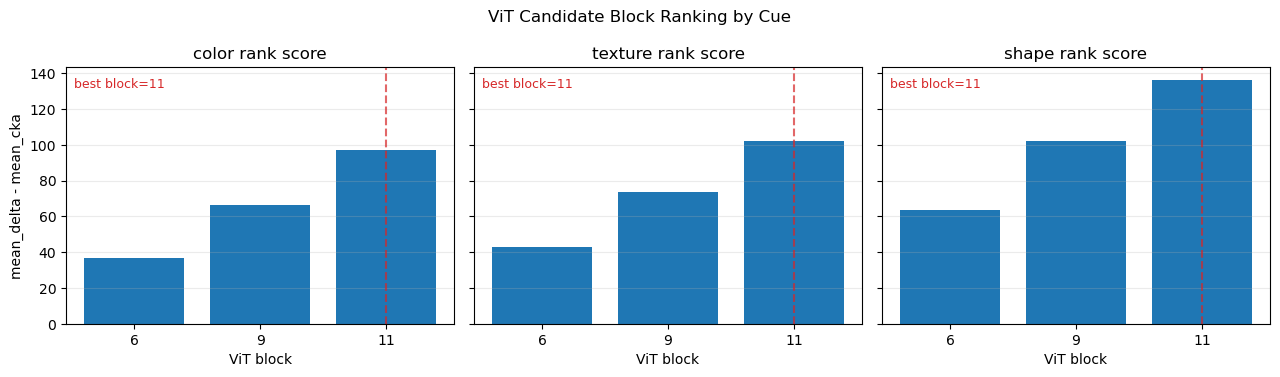

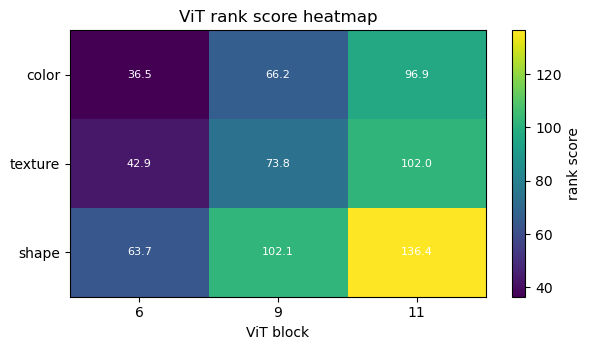

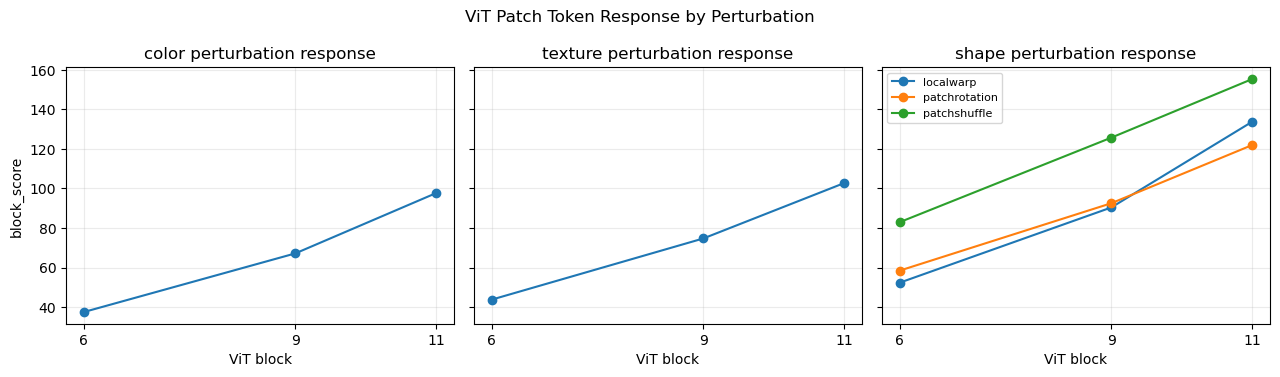

In [8]:
# Cell 6b. ViT Patch Token Ranking Plots

vit_block_plot_df = vit_block_df.copy() if isinstance(vit_block_df, pd.DataFrame) else pd.DataFrame()
vit_block_csv = phase1_dir / 'phase1_vit_block_ranking.csv'
if vit_block_plot_df.empty and vit_block_csv.exists():
    vit_block_plot_df = pd.read_csv(vit_block_csv)

if vit_block_plot_df.empty:
    print('No ViT block ranking data found. Run Cell 6 first.')
else:
    ensure_dir(phase1_dir / 'figures')
    vit_block_summary_df = (
        vit_block_plot_df
        .groupby(['cue', 'block'], as_index=False)
        .agg(
            mean_delta=('block_score', 'mean'),
            mean_cka=('cka', 'mean'),
            mean_cosine_distance=('cosine_distance', 'mean'),
            mean_l2_distance=('l2_distance', 'mean'),
            n_perturbations=('perturbation', 'nunique'),
        )
    )
    vit_block_summary_df['rank_score'] = vit_block_summary_df['mean_delta'] - vit_block_summary_df['mean_cka']
    vit_block_summary_df = vit_block_summary_df.sort_values(['cue', 'rank_score'], ascending=[True, False])
    display(vit_block_summary_df)

    cue_order = [cue for cue in ['color', 'texture', 'shape'] if cue in set(vit_block_summary_df['cue'])]
    blocks = sorted(vit_block_summary_df['block'].astype(int).unique().tolist())

    fig, axes = plt.subplots(1, len(cue_order), figsize=(4.3 * len(cue_order), 3.8), sharey=True)
    axes = np.asarray(axes).reshape(-1)
    for ax, cue in zip(axes, cue_order):
        sub = vit_block_summary_df[vit_block_summary_df['cue'] == cue].sort_values('block')
        ax.bar(sub['block'].astype(str), sub['rank_score'])
        ax.set_title(f'{cue} rank score')
        ax.set_xlabel('ViT block')
        ax.grid(axis='y', alpha=0.25)
        best = sub.sort_values('rank_score', ascending=False).iloc[0]
        ax.axvline(list(sub['block'].astype(str)).index(str(int(best['block']))), color='tab:red', linestyle='--', alpha=0.7)
        ax.text(
            0.02,
            0.96,
            f"best block={int(best['block'])}",
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=9,
            color='tab:red',
        )
    axes[0].set_ylabel('mean_delta - mean_cka')
    fig.suptitle('ViT Candidate Block Ranking by Cue')
    fig.tight_layout()
    fig.savefig(phase1_dir / 'figures' / 'vit_block_rank_score_by_cue.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    heatmap_df = (
        vit_block_summary_df
        .pivot(index='cue', columns='block', values='rank_score')
        .reindex(cue_order)
        .reindex(columns=blocks)
    )
    fig, ax = plt.subplots(figsize=(1.2 * len(blocks) + 2.5, 3.6))
    im = ax.imshow(heatmap_df.to_numpy(dtype=float), aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(len(blocks)))
    ax.set_xticklabels(blocks)
    ax.set_yticks(np.arange(len(cue_order)))
    ax.set_yticklabels(cue_order)
    ax.set_xlabel('ViT block')
    ax.set_title('ViT rank score heatmap')
    for y, cue in enumerate(cue_order):
        for x, block in enumerate(blocks):
            value = heatmap_df.loc[cue, block]
            if pd.notna(value):
                ax.text(x, y, f'{value:.1f}', ha='center', va='center', color='white', fontsize=8)
    fig.colorbar(im, ax=ax, label='rank score')
    fig.tight_layout()
    fig.savefig(phase1_dir / 'figures' / 'vit_block_rank_score_heatmap.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(1, len(cue_order), figsize=(4.3 * len(cue_order), 3.8), sharey=True)
    axes = np.asarray(axes).reshape(-1)
    for ax, cue in zip(axes, cue_order):
        cue_df = vit_block_plot_df[vit_block_plot_df['cue'] == cue].copy()
        for perturbation, sub in cue_df.groupby('perturbation'):
            sub = sub.sort_values('block')
            ax.plot(sub['block'], sub['block_score'], marker='o', label=perturbation)
        ax.set_title(f'{cue} perturbation response')
        ax.set_xlabel('ViT block')
        ax.set_xticks(blocks)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel('block_score')
    axes[-1].legend(fontsize=8, loc='best')
    fig.suptitle('ViT Patch Token Response by Perturbation')
    fig.tight_layout()
    fig.savefig(phase1_dir / 'figures' / 'vit_block_perturbation_response.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)


In [9]:
# Cell 7. Visualization Utilities

if RUN_RESNET_VIS:
    resnet_top_channels = resnet_top_channels or load_json_if_exists(phase1_dir / 'phase1_resnet_top_channels.json', {})
    resnet_vis_requirements = required_resnet_visualization_inputs(
        resnet_top_channels,
        VIS_IMAGE_POSITIONS,
        perturbation_to_cue,
        RESNET_TARGET_LAYER_NAMES,
    )
    if not resnet_outputs_cover_visualization(resnet_outputs, resnet_vis_requirements):
        print(
            'Building small ResNet visualization cache: '
            f"images={resnet_vis_requirements['image_positions']}, "
            f"layers={resnet_vis_requirements['layers']}, "
            f"perturbations={resnet_vis_requirements['perturbations']}"
        )
        resnet_vis_spec = make_resnet50_spec()
        resnet_outputs = extract_resnet_outputs_for_visualization(
            resnet_vis_spec.model,
            resnet_vis_spec,
            imagenet_200_spec,
            resnet_vis_requirements['perturbations'],
            resnet_vis_requirements['layers'],
            resnet_vis_requirements['image_positions'],
            selected_indices,
            build_loader,
            data_config,
            DTYPE_FOR_CACHE,
            DEVICE,
        )
        resnet_vis_spec.model.cpu()
        del resnet_vis_spec
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    for cue, records in resnet_top_channels.items():
        perturbation = next((p for p, c in perturbation_to_cue.items() if c == cue), None)
        if perturbation is None:
            continue
        for record in records[:3]:
            layer = record['layer']
            channel = int(record['channel'])
            for image_pos in VIS_IMAGE_POSITIONS:
                raw_image, _ = base_ds[selected_indices[image_pos]]
                save_path = phase1_dir / 'figures' / f'resnet_{layer}_channel_{channel}_{perturbation}_image_{image_pos}.png'
                clean_cache_idx = resnet_cached_image_index(resnet_outputs, 'original', image_pos)
                pert_cache_idx = resnet_cached_image_index(resnet_outputs, perturbation, image_pos)
                plot_resnet_channel_comparison(
                    raw_image,
                    resnet_outputs['original']['activations'][layer][clean_cache_idx],
                    resnet_outputs[perturbation]['activations'][layer][pert_cache_idx],
                    layer,
                    channel,
                    perturbation,
                    perturbation_to_cue,
                    save_path,
                )

if RUN_VIT_VIS:
    vit_vis_outputs = globals().get('vit_vis_outputs', {})
    vit_top_blocks = vit_top_blocks or load_json_if_exists(phase1_dir / 'phase1_vit_top_blocks.json', {})
    vit_vis_requirements = required_vit_visualization_inputs(
        vit_top_blocks,
        VIS_IMAGE_POSITIONS,
        perturbation_to_cue,
        VIT_CANDIDATE_BLOCKS,
    )
    if not vit_outputs_cover_visualization(vit_vis_outputs, vit_vis_requirements, require_attention=True):
        print(
            'Building small ViT visualization cache: '
            f"images={vit_vis_requirements['image_positions']}, "
            f"blocks={vit_vis_requirements['blocks']}, "
            f"perturbations={vit_vis_requirements['perturbations']}"
        )
        vit_vis_spec = make_vit_b16_spec()
        vit_vis_outputs = extract_vit_outputs_for_visualization(
            vit_vis_spec.model,
            vit_vis_spec,
            imagenet_200_spec,
            vit_vis_requirements['perturbations'],
            vit_vis_requirements['blocks'],
            vit_vis_requirements['image_positions'],
            selected_indices,
            build_loader,
            data_config,
            DEVICE,
            dtype_for_cache=DTYPE_FOR_CACHE,
        )
        vit_vis_spec.model.cpu()
        del vit_vis_spec
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    vit_visual_resize_size = vit_vis_outputs.get('_meta', {}).get('resize_size', transform_hparams.resize_size)
    vit_visual_transforms = build_visual_transforms(
        vit_vis_requirements['perturbations'],
        transform_hparams,
        resize_size=vit_visual_resize_size,
    )
    for cue, records in vit_top_blocks.items():
        perturbation = next((p for p, c in perturbation_to_cue.items() if c == cue), None)
        if perturbation is None:
            continue
        for record in records[:3]:
            block = int(record['block'])
            for image_pos in VIS_IMAGE_POSITIONS:
                raw_image, _ = base_ds[selected_indices[image_pos]]
                original_input = vit_visual_transforms['original'](raw_image.copy())
                transformed_input = vit_visual_transforms[perturbation](raw_image.copy())
                maps = vit_patch_delta_maps(vit_vis_outputs, block, perturbation, image_pos)
                clean_cache_idx = vit_cached_image_index(vit_vis_outputs, 'original', image_pos)
                pert_cache_idx = vit_cached_image_index(vit_vis_outputs, perturbation, image_pos)
                save_path = phase1_dir / 'figures' / f'vit_block_{block}_{perturbation}_image_{image_pos}_attn_activation.png'
                plot_vit_attention_activation_summary(
                    original_input,
                    transformed_input,
                    vit_vis_outputs['original']['cls_attention'][block][clean_cache_idx],
                    vit_vis_outputs[perturbation]['cls_attention'][block][pert_cache_idx],
                    maps['patch_norm_clean'],
                    maps['patch_norm_perturbed'],
                    maps['patch_delta'],
                    block,
                    perturbation,
                    perturbation_to_cue,
                    save_path,
                )

print('Visualization helpers ready.')




Building small ViT visualization cache: images=[0, 1, 2], blocks=[11, 9, 6], perturbations=['original', 'grayscale', 'bilateral', 'patchshuffle']


ViT vis cache original:   0%|          | 0/1 [00:00<?, ?it/s]

ViT vis cache grayscale:   0%|          | 0/1 [00:00<?, ?it/s]

ViT vis cache bilateral:   0%|          | 0/1 [00:00<?, ?it/s]

ViT vis cache patchshuffle:   0%|          | 0/1 [00:00<?, ?it/s]

Visualization helpers ready.


## Phase 2. SAE Prototype

This starts with a Vanilla L1 SAE smoke test. The point is to validate activation cache, reconstruction quality, and future replacement/intervention wiring before moving to PatchSAE or other variants.


In [10]:
# Cell 8. SAE Prototype Training


sae_train_results = globals().get('sae_train_results', [])
selected_sae_run_dir = globals().get('selected_sae_run_dir', None)

SAE_CACHE_MAX_IMAGES = None  # None이면 RAM 예산 안에서 가능한 만큼 사용
SAE_CACHE_RAM_BUDGET_GB = None  # None이면 현재 MemAvailable의 일부를 사용
SAE_CACHE_RAM_FRACTION = 0.45
SAE_CACHE_ESTIMATE_SAFETY = 1.35
SAE_ESTIMATED_VIT_TOKENS_PER_IMAGE = 196
SAE_ESTIMATED_VIT_INPUT_DIM = 768
SAE_LATENT_CACHE_DTYPE = torch.float16
SAE_ENCODE_BATCH_SIZE = 2048


class VanillaL1SAE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = int(input_dim)
        self.hidden_dim = int(hidden_dim)
        self.encoder = nn.Linear(self.input_dim, self.hidden_dim)
        self.decoder = nn.Linear(self.hidden_dim, self.input_dim)
        nn.init.kaiming_uniform_(self.encoder.weight, a=math.sqrt(5))
        nn.init.zeros_(self.encoder.bias)
        nn.init.kaiming_uniform_(self.decoder.weight, a=math.sqrt(5))
        nn.init.zeros_(self.decoder.bias)

    def encode(self, x):
        return F.relu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z


@torch.no_grad()
def normalize_sae_decoder_columns(sae:VanillaL1SAE, eps=1e-8):
    sae.decoder.weight.div_(sae.decoder.weight.norm(dim=0, keepdim=True).clamp_min(eps))


def vit_token_scope_for_block(block):
    if int(block) != int(VIT_FINAL_BLOCK_INDEX):
        return 'patch'
    if VIT_FINAL_BLOCK_TOKEN_SCOPE not in {'cls', 'clspatch'}:
        raise ValueError("VIT_FINAL_BLOCK_TOKEN_SCOPE must be 'cls' or 'clspatch'.")
    return VIT_FINAL_BLOCK_TOKEN_SCOPE


def should_include_vit_cls_token(block):
    return vit_token_scope_for_block(block) in {'cls', 'clspatch'}


def estimated_sae_vit_tokens_per_image():
    token_scope = vit_token_scope_for_block(SAE_TARGET_BLOCK)
    if token_scope == 'cls':
        return 1
    extra_cls = 1 if token_scope == 'clspatch' else 0
    return SAE_ESTIMATED_VIT_TOKENS_PER_IMAGE + extra_cls


def vit_tokens_to_matrix(tokens, cls_tokens=None, token_scope='patch'):
    B, N, D = tokens.shape
    grid = int(math.sqrt(N))
    if token_scope == 'cls':
        if cls_tokens is None:
            raise ValueError("cls_tokens is required when token_scope='cls'.")
        X = cls_tokens.reshape(B, D).float()
        metadata = pd.DataFrame({
            'image_pos': np.arange(B),
            'token_type': 'cls',
            'patch_id': -1,
        })
        tokens_per_image = 1
    elif token_scope == 'patch':
        X = tokens.reshape(B * N, D).float()
        metadata = pd.DataFrame({
            'image_pos': np.repeat(np.arange(B), N),
            'token_type': 'patch',
            'patch_id': np.tile(np.arange(N), B),
        })
        tokens_per_image = N
    elif token_scope == 'clspatch':
        if cls_tokens is None:
            raise ValueError("cls_tokens is required when token_scope='clspatch'.")
        cls_tokens = cls_tokens.reshape(B, 1, D)
        all_tokens = torch.cat([cls_tokens, tokens], dim=1)
        X = all_tokens.reshape(B * (N + 1), D).float()
        metadata = pd.DataFrame({
            'image_pos': np.repeat(np.arange(B), N + 1),
            'token_type': np.tile(['cls'] + ['patch'] * N, B),
            'patch_id': np.tile(np.concatenate([np.array([-1]), np.arange(N)]), B),
        })
        tokens_per_image = N + 1
    else:
        raise ValueError(f'Unknown token_scope: {token_scope}')
    if grid * grid == N:
        patch_mask = metadata['token_type'].eq('patch')
        metadata.loc[patch_mask, 'patch_y'] = metadata.loc[patch_mask, 'patch_id'] // grid
        metadata.loc[patch_mask, 'patch_x'] = metadata.loc[patch_mask, 'patch_id'] % grid
    return X, metadata, {
        'num_images': B,
        'tokens_per_image': tokens_per_image,
        'patch_tokens_per_image': N,
        'input_dim': D,
        'grid': grid,
        'include_cls_token': cls_tokens is not None,
        'token_scope': token_scope,
    }


def resnet_activations_to_matrix(activations):
    B, C, H, W = activations.shape
    X = activations.permute(0, 2, 3, 1).reshape(B * H * W, C).float()
    metadata = pd.DataFrame({
        'image_pos': np.repeat(np.arange(B), H * W),
        'spatial_id': np.tile(np.arange(H * W), B),
    })
    metadata['spatial_y'] = metadata['spatial_id'] // W
    metadata['spatial_x'] = metadata['spatial_id'] % W
    return X, metadata, {'num_images': B, 'tokens_per_image': H * W, 'input_dim': C, 'height': H, 'width': W}


def build_sae_activation_matrix(source_type, perturbation='original', target_block=None, target_layer=None):
    if source_type == 'vit':
        if not vit_outputs:
            raise RuntimeError('Run Cell 6 first or let Cell 8 build vit_outputs for SAE.')
        block = SAE_TARGET_BLOCK if target_block is None else target_block
        tokens = vit_outputs[perturbation]['patch_tokens'][block]
        token_scope = vit_token_scope_for_block(block)
        include_cls_token = token_scope in {'cls', 'clspatch'}
        cls_tokens = vit_outputs[perturbation]['cls_tokens'][block] if include_cls_token else None
        X, metadata, meta = vit_tokens_to_matrix(tokens, cls_tokens=cls_tokens, token_scope=token_scope)
        meta.update({
            'source_type': 'vit',
            'target_block': block,
            'perturbation': perturbation,
            'include_cls_token': include_cls_token,
            'token_scope': token_scope,
        })
        return X, metadata, meta

    if source_type == 'resnet':
        if not resnet_outputs:
            raise RuntimeError('Run Cell 4 first; resnet_outputs is empty.')
        layer = SAE_TARGET_LAYER if target_layer is None else target_layer
        activations = resnet_outputs[perturbation]['activations'][layer]
        X, metadata, meta = resnet_activations_to_matrix(activations)
        meta.update({'source_type': 'resnet', 'target_layer': layer, 'perturbation': perturbation})
        return X, metadata, meta

    raise ValueError(f'Unknown source_type: {source_type}')


def split_activation_matrix(X, metadata, max_train_tokens, max_val_tokens, seed=SEED):
    n = X.shape[0]
    if n < 2:
        raise ValueError(f'Need at least 2 tokens for train/val split, got {n}.')
    rng = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=rng)
    n_val = min(max_val_tokens, max(1, n // 5), n - 1)
    n_train = min(max_train_tokens, n - n_val)
    if n_train < 1 or n_val < 1:
        raise ValueError(f'Invalid SAE split: train={n_train}, val={n_val}, total={n}.')
    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    return X[train_idx], X[val_idx], metadata.iloc[train_idx.numpy()].reset_index(drop=True), metadata.iloc[val_idx.numpy()].reset_index(drop=True)


def dtype_nbytes(dtype):
    return torch.empty((), dtype=dtype).element_size()


def available_ram_bytes():
    meminfo = Path('/proc/meminfo')
    if not meminfo.exists():
        return None
    for line in meminfo.read_text().splitlines():
        if line.startswith('MemAvailable:'):
            return int(line.split()[1]) * 1024
    return None


def max_sae_expansion_factor():
    return max(float(cfg.get('expansion_factor', 1.0)) for cfg in SAE_SWEEP)


def estimate_sae_vit_bytes_per_image(perturbation_count):
    tokens_per_image = estimated_sae_vit_tokens_per_image()
    input_dim = SAE_ESTIMATED_VIT_INPUT_DIM
    hidden_dim = int(input_dim * max_sae_expansion_factor())
    patch_cache = perturbation_count * tokens_per_image * input_dim * dtype_nbytes(DTYPE_FOR_CACHE)
    original_matrix_work = 2 * tokens_per_image * input_dim * dtype_nbytes(torch.float32)
    latent_work = tokens_per_image * hidden_dim * (dtype_nbytes(SAE_LATENT_CACHE_DTYPE) + 1)
    return int((patch_cache + original_matrix_work + latent_work) * SAE_CACHE_ESTIMATE_SAFETY)


def choose_sae_vit_cache_max_batches(dataset_size, perturbation_count):
    total_batches = math.ceil(dataset_size / DATA_BATCH_SIZE)
    requested_tokens = SAE_MAX_TRAIN_TOKENS + SAE_MAX_VAL_TOKENS
    min_images_for_requested_tokens = math.ceil(requested_tokens / estimated_sae_vit_tokens_per_image())

    explicit_image_cap = SAE_CACHE_MAX_IMAGES is not None
    if explicit_image_cap:
        target_images = int(SAE_CACHE_MAX_IMAGES)
        budget_label = f'explicit image cap={target_images:,}'
    else:
        if SAE_CACHE_RAM_BUDGET_GB is not None:
            budget_bytes = int(SAE_CACHE_RAM_BUDGET_GB * (1024 ** 3))
            budget_label = f'explicit RAM budget={SAE_CACHE_RAM_BUDGET_GB:g}GB'
        else:
            ram_bytes = available_ram_bytes()
            budget_bytes = int(ram_bytes * SAE_CACHE_RAM_FRACTION) if ram_bytes is not None else None
            budget_label = (
                f'{SAE_CACHE_RAM_FRACTION:.0%} of MemAvailable'
                if ram_bytes is not None else 'fallback'
            )

        if budget_bytes is None:
            target_images = min(dataset_size, max(min_images_for_requested_tokens, 512))
        else:
            bytes_per_image = estimate_sae_vit_bytes_per_image(perturbation_count)
            target_images = max(1, budget_bytes // max(1, bytes_per_image))
            target_images = max(target_images, min_images_for_requested_tokens)

    target_images = max(1, min(dataset_size, int(target_images)))
    if target_images >= dataset_size:
        print(f'SAE ViT cache uses all {dataset_size:,} images ({budget_label}).')
        return None

    max_batches = max(1, target_images // DATA_BATCH_SIZE)
    if explicit_image_cap and max_batches * DATA_BATCH_SIZE < min_images_for_requested_tokens:
        print(
            '[WARN] SAE_CACHE_MAX_IMAGES is below the requested train+val token budget; '
            'SAE will use fewer tokens than requested.'
        )
    elif max_batches * DATA_BATCH_SIZE < min_images_for_requested_tokens:
        max_batches = min(total_batches, math.ceil(min_images_for_requested_tokens / DATA_BATCH_SIZE))
    actual_images = min(dataset_size, max_batches * DATA_BATCH_SIZE)
    print(
        'SAE ViT cache cap: '
        f'{actual_images:,}/{dataset_size:,} images, max_batches={max_batches}, '
        f'{budget_label}.'
    )
    return max_batches


def compute_preprocess_stats(X, use_std=True, eps=1e-6):
    mean = X.mean(dim=0)
    if use_std:
        std = X.std(dim=0).clamp_min(eps)
    else:
        std = torch.ones_like(mean)
    return {'mean': mean.cpu(), 'std': std.cpu(), 'use_std': bool(use_std), 'eps': eps}


def apply_preprocess(X, stats):
    mean = stats['mean'].to(X.device)
    std = stats['std'].to(X.device)
    return (X - mean) / std


def undo_preprocess(X_norm, stats):
    mean = stats['mean'].to(X_norm.device)
    std = stats['std'].to(X_norm.device)
    return X_norm * std + mean


@torch.no_grad()
def evaluate_sae_reconstruction(sae, X_norm, batch_size=8192, device=DEVICE, threshold=LATENT_ACTIVE_THRESHOLD):
    sae.eval().to(device)
    X_norm = X_norm.cpu().float()
    n = X_norm.shape[0]
    if n == 0:
        raise ValueError('Cannot evaluate SAE reconstruction with an empty validation matrix.')
    total_elements = X_norm.numel()
    ss_tot = (X_norm - X_norm.mean(dim=0, keepdim=True)).pow(2).sum().clamp_min(1e-12)
    var = X_norm.var().item()

    ss_res = 0.0
    cosine_sum = 0.0
    l0_sum = 0.0
    freq_counts = None
    for start in range(0, X_norm.shape[0], batch_size):
        xb_cpu = X_norm[start:start + batch_size]
        xb = xb_cpu.to(device)
        x_hat, z = sae(xb)
        x_hat_cpu = x_hat.detach().cpu().float()
        z_active = z.detach().cpu() > threshold

        ss_res += float((xb_cpu - x_hat_cpu).pow(2).sum().item())
        cosine_sum += float(F.cosine_similarity(xb_cpu, x_hat_cpu, dim=1).sum().item())
        l0_sum += float(z_active.float().sum(dim=1).sum().item())
        counts = z_active.sum(dim=0).float()
        freq_counts = counts if freq_counts is None else freq_counts + counts

    if freq_counts is None:
        raise RuntimeError('SAE evaluation did not process any batches.')
    mse = ss_res / max(1, total_elements)
    nmse = mse / (var + 1e-12)
    r2 = float(1.0 - ss_res / float(ss_tot.item()))
    cosine = cosine_sum / max(1, n)
    l0 = l0_sum / max(1, n)
    freq = freq_counts / max(1, n)
    dead_ratio = float((freq < 1e-6).float().mean().item())
    high_freq_ratio = float((freq > HIGH_FREQ_THRESHOLD).float().mean().item())
    return {
        'mse': mse,
        'variance': var,
        'nmse': nmse,
        'r2': r2,
        'cosine': cosine,
        'l0': l0,
        'dead_latent_ratio': dead_ratio,
        'mean_latent_frequency': float(freq.mean().item()),
        'max_latent_frequency': float(freq.max().item()),
        'high_frequency_ratio': high_freq_ratio,
    }


def train_vanilla_l1_sae(X_train_norm, X_val_norm, config, run_dir, verbose=1):
    input_dim = X_train_norm.shape[1]
    hidden_dim = int(config['expansion_factor'] * input_dim)
    sae = VanillaL1SAE(input_dim=input_dim, hidden_dim=hidden_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(sae.parameters(), lr=config['lr'])
    run_dir = ensure_dir(run_dir)
    normalize_decoder = bool(config.get('normalize_decoder', SAE_NORMALIZE_DECODER))
    active_threshold = float(config.get('active_threshold', LATENT_ACTIVE_THRESHOLD))
    if normalize_decoder:
        normalize_sae_decoder_columns(sae)

    logs = []
    for epoch in range(config.get('epochs', SAE_EPOCHS)):
        sae.train()
        perm = torch.randperm(X_train_norm.shape[0])
        pbar = tqdm(range(0, X_train_norm.shape[0], config.get('batch_size', SAE_BATCH_SIZE)), desc=f'SAE epoch {epoch + 1}', leave=False)
        for start in pbar:
            idx = perm[start:start + config.get('batch_size', SAE_BATCH_SIZE)]
            xb = X_train_norm[idx].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            x_hat, z = sae(xb)
            mse = F.mse_loss(x_hat, xb)
            l1_sum = z.sum(dim=1).mean()
            batch_l0 = (z.detach() > active_threshold).float().sum(dim=1).mean()
            loss = mse + config['lambda_l1'] * l1_sum
            loss.backward()
            optimizer.step()
            if normalize_decoder:
                normalize_sae_decoder_columns(sae)
            logs.append({
                'epoch': epoch + 1,
                'loss': float(loss.item()),
                'mse': float(mse.item()),
                'l1_sum': float(l1_sum.item()),
                'l0': float(batch_l0.item()),
            })
            pbar.set_postfix(loss=f'{loss.item():.4g}', mse=f'{mse.item():.4g}', l1_sum=f'{l1_sum.item():.4g}', l0=f'{batch_l0.item():.0f}')
        if (epoch + 1) % verbose == 0:
            print(f'Finished SAE epoch {epoch + 1}/{config.get("epochs", SAE_EPOCHS)} | Loss: {loss.item():.4g} | MSE: {mse.item():.4g} | L1 sum: {l1_sum.item():.4g} | L0: {batch_l0.item():.0f}')
        
    metrics = evaluate_sae_reconstruction(sae, X_val_norm, batch_size=config.get('batch_size', SAE_BATCH_SIZE))
    torch.save(
        {
            'state_dict': sae.state_dict(),
            'input_dim': input_dim,
            'hidden_dim': hidden_dim,
            'config': config,
            'metrics': metrics,
        },
        run_dir / 'sae.pt',
    )
    pd.DataFrame(logs).to_csv(run_dir / 'train_log.csv', index=False)
    save_json(config, run_dir / 'sae_train_config.json')
    save_json(metrics, run_dir / 'sae_metrics.json')
    return sae, metrics


def select_sae_sweep_result(results_df):
    if results_df.empty:
        raise ValueError('No SAE sweep results to select from.')
    l0_min, l0_max = SAE_TARGET_L0_RANGE
    target_center = math.sqrt(l0_min * l0_max)
    results_df = results_df.copy()
    results_df['passes_min_r2'] = results_df['r2'] >= SAE_MIN_R2
    results_df['within_l0_target'] = results_df['l0'].between(l0_min, l0_max)
    results_df['l0_target_distance'] = np.abs(np.log(results_df['l0'].clip(lower=1e-12) / target_center))
    eligible = results_df[results_df['passes_min_r2']]
    if eligible.empty:
        best = results_df.sort_values(['r2', 'nmse'], ascending=[False, True]).iloc[0]
        raise RuntimeError(
            f"No SAE run reached SAE_MIN_R2={SAE_MIN_R2:.2f}. "
            f"Best r2={best['r2']:.3f}, l0={best['l0']:.1f}, run={best['run_dir']}. "
            "Inspect phase2_sae/sae_sweep_results_raw.csv and expand SAE_SWEEP or training budget."
        )
    if eligible['within_l0_target'].any():
        ranked = eligible[eligible['within_l0_target']].sort_values(['r2', 'nmse'], ascending=[False, True])
        selection_reason = 'within_l0_target_best_r2'
    else:
        ranked = eligible.sort_values(['l0_target_distance', 'r2', 'nmse'], ascending=[True, False, True])
        selection_reason = 'closest_l0_outside_target_min_r2_passed'
    selected_idx = ranked.index[0]
    results_df['selected'] = False
    results_df['selection_reason'] = ''
    results_df.loc[selected_idx, 'selected'] = True
    results_df.loc[selected_idx, 'selection_reason'] = selection_reason
    return results_df


if RUN_SAE_TRAINING:
    if SAE_SOURCE_TYPE == 'vit' and not vit_outputs:
        sae_perturbations = perturbations if RUN_SAE_VALIDATION else ['original']
        sae_cache_max_batches = choose_sae_vit_cache_max_batches(
            dataset_size=len(selected_indices),
            perturbation_count=len(sae_perturbations),
        )
        print(
            'Building ViT token cache for SAE: '
            f'blocks={[SAE_TARGET_BLOCK]}, perturbations={sae_perturbations}'
        )
        sae_vit_spec = make_vit_b16_spec()
        vit_outputs = extract_vit_outputs_for_cache(
            sae_vit_spec.model,
            sae_vit_spec,
            imagenet_200_spec,
            sae_perturbations,
            [SAE_TARGET_BLOCK],
            build_loader,
            DEVICE,
            dtype_for_cache=DTYPE_FOR_CACHE,
            max_batches=sae_cache_max_batches,
        )
        sae_vit_spec.model.cpu()
        del sae_vit_spec
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    X, token_metadata, source_meta = build_sae_activation_matrix(
        SAE_SOURCE_TYPE,
        perturbation='original',
        target_block=SAE_TARGET_BLOCK,
        target_layer=SAE_TARGET_LAYER,
    )
    print(f'SAE source matrix: {X.shape[0]:,} tokens x {X.shape[1]:,} dims')
    X_train, X_val, train_metadata, val_metadata = split_activation_matrix(
        X,
        token_metadata,
        SAE_MAX_TRAIN_TOKENS,
        SAE_MAX_VAL_TOKENS,
    )
    print(f'SAE split: train={X_train.shape[0]:,} tokens, val={X_val.shape[0]:,} tokens')
    preprocess_stats = compute_preprocess_stats(X_train, use_std=SAE_USE_STD)
    X_train_norm = apply_preprocess(X_train, preprocess_stats)
    X_val_norm = apply_preprocess(X_val, preprocess_stats)

    sae_train_results = []
    for sweep_idx, base_config in enumerate(SAE_SWEEP):
        token_scope = source_meta.get('token_scope', 'clspatch' if source_meta.get('include_cls_token', False) else 'patch')
        config = {
            **base_config,
            'epochs': SAE_EPOCHS,
            'batch_size': SAE_BATCH_SIZE,
            'source_type': SAE_SOURCE_TYPE,
            'target_block': SAE_TARGET_BLOCK if SAE_SOURCE_TYPE == 'vit' else None,
            'target_layer': SAE_TARGET_LAYER if SAE_SOURCE_TYPE == 'resnet' else None,
            'include_cls_token': bool(source_meta.get('include_cls_token', False)),
            'token_scope': token_scope,
            'max_train_tokens': int(X_train.shape[0]),
            'max_val_tokens': int(X_val.shape[0]),
            'use_std': SAE_USE_STD,
            'normalize_decoder': SAE_NORMALIZE_DECODER,
            'active_threshold': LATENT_ACTIVE_THRESHOLD,
            'target_l0_min': SAE_TARGET_L0_RANGE[0],
            'target_l0_max': SAE_TARGET_L0_RANGE[1],
            'min_r2': SAE_MIN_R2,
        }
        source_tag = f"b{config['target_block']}_{token_scope}" if SAE_SOURCE_TYPE == 'vit' else f"{config['target_layer']}"
        run_name = f"{SAE_SOURCE_TYPE}_{source_tag}_{SAE_RUN_PREFIX}_{sweep_idx:03d}_exp{config['expansion_factor']}_l1{config['lambda_l1']:.0e}"
        run_dir = ensure_dir(phase2_dir / run_name)
        torch.save(preprocess_stats, run_dir / 'preprocess_stats.pt')
        save_json(source_meta, run_dir / 'source_meta.json')
        train_metadata.to_csv(run_dir / 'train_token_metadata.csv', index=False)
        val_metadata.to_csv(run_dir / 'val_token_metadata.csv', index=False)
        sae, metrics = train_vanilla_l1_sae(X_train_norm, X_val_norm, config, run_dir, verbose=SAE_TRAIN_VERBOSE)
        sae_train_results.append({'run_dir': str(run_dir), **config, **metrics})

    raw_sae_results_df = pd.DataFrame(sae_train_results)
    raw_sae_results_df.to_csv(phase2_dir / 'sae_sweep_results_raw.csv', index=False)
    sae_results_df = select_sae_sweep_result(raw_sae_results_df)
    sae_results_df = sae_results_df.sort_values(
        ['selected', 'passes_min_r2', 'within_l0_target', 'r2', 'l0_target_distance'],
        ascending=[False, False, False, False, True],
    )
    sae_results_df.to_csv(phase2_dir / 'sae_sweep_results.csv', index=False)
    selected_row = sae_results_df.loc[sae_results_df['selected']].iloc[0]
    selected_sae_run_dir = Path(selected_row['run_dir'])
    if not bool(selected_row['within_l0_target']):
        print(
            '[WARN] Selected SAE is outside target L0 range '
            f"{SAE_TARGET_L0_RANGE}: l0={selected_row['l0']:.1f}. "
            'Expand SAE_SWEEP or adjust SAE_TARGET_L0_RANGE if latent groups remain empty.'
        )
    print(f'Selected SAE run: {selected_sae_run_dir}')
    display(sae_results_df)
else:
    print('RUN_SAE_TRAINING=False, skipped SAE smoke training.')




SAE ViT cache cap: 1,024/4,096 images, max_batches=4, 45% of MemAvailable.
Building ViT token cache for SAE: blocks=[9], perturbations=['original', 'grayscale', 'bilateral', 'patchshuffle', 'patchrotation', 'localwarp']


ViT cache original:   0%|          | 0/16 [00:00<?, ?it/s]

ViT cache grayscale:   0%|          | 0/16 [00:00<?, ?it/s]

ViT cache bilateral:   0%|          | 0/16 [00:00<?, ?it/s]

ViT cache patchshuffle:   0%|          | 0/16 [00:00<?, ?it/s]

...

SAE epoch 498:   0%|          | 0/25 [00:00<?, ?it/s]

SAE epoch 499:   0%|          | 0/25 [00:00<?, ?it/s]

SAE epoch 500:   0%|          | 0/25 [00:00<?, ?it/s]

Finished SAE epoch 500/500 | Loss: 0.6933 | MSE: 0.5446 | L1 sum: 14.86 | L0: 6
Selected SAE run: outputs/feature_disentangle/phase2_sae/vit_b9_patch_sparse_suml1_004_exp8_l11e-03


,run_dir,expansion_factor,lambda_l1,lr,epochs,batch_size,source_type,target_block,target_layer,include_cls_token,...,l0,dead_latent_ratio,mean_latent_frequency,max_latent_frequency,high_frequency_ratio,passes_min_r2,within_l0_target,l0_target_distance,selected,selection_reason
4,outputs/feature_disentangle/phase2_sae/vit_b9_...,8,0.001,0.0003,500,2048,vit,9,None,False,...,330.1628,0.000000,0.053737,0.1094,0.0,True,True,0.438739,True,within_l0_target_best_r2
0,outputs/feature_disentangle/phase2_sae/vit_b9_...,4,0.001,0.0003,500,2048,vit,9,None,False,...,310.9732,0.000000,0.101228,0.1892,0.0,True,True,0.498618,False,
5,outputs/feature_disentangle/phase2_sae/vit_b9_...,8,0.003,0.0003,500,2048,vit,9,None,False,...,104.9002,0.000000,0.017074,0.0525,0.0,False,False,1.585315,False,
1,outputs/feature_disentangle/phase2_sae/vit_b9_...,4,0.003,0.0003,500,2048,vit,9,None,False,...,69.8680,0.000000,0.022743,0.0767,0.0,False,False,1.991717,False,
2,outputs/feature_disentangle/phase2_sae/vit_b9_...,4,0.010,0.0003,500,2048,vit,9,None,False,...,17.2134,0.042969,0.005603,0.0619,0.0,False,False,3.392636,False,
7,outputs/feature_disentangle/phase2_sae/vit_b9_...,8,0.010,0.0003,500,2048,vit,9,None,False,...,25.0974,0.040527,0.004085,0.0712,0.0,False,False,3.015560,False,
3,outputs/feature_disentangle/phase2_sae/vit_b9_...,4,0.050,0.0003,500,2048,vit,9,None,False,...,8.2463,0.017904,0.002684,0.0325,0.0,False,False,4.128560,False,
6,outputs/feature_disentangle/phase2_sae/vit_b9_...,8,0.050,0.0003,500,2048,vit,9,None,False,...,16.1346,0.018392,0.002626,0.0061,0.0,False,False,3.457359,False,


In [11]:
# Cell 9. SAE Validation Plots and Latent Groups

selected_sae_path = SELECTED_SAE_RUN_DIR or selected_sae_run_dir

latent_frequency_df = globals().get('latent_frequency_df', pd.DataFrame())
latent_sensitivity_df = globals().get('latent_sensitivity_df', pd.DataFrame())
latent_groups = globals().get('latent_groups', {})


def load_sae_run(run_dir):
    run_dir = Path(run_dir)
    checkpoint = torch.load(run_dir / 'sae.pt', map_location='cpu')
    sae = VanillaL1SAE(checkpoint['input_dim'], checkpoint['hidden_dim'])
    sae.load_state_dict(checkpoint['state_dict'])
    sae.eval()
    stats = torch.load(run_dir / 'preprocess_stats.pt', map_location='cpu')
    with open(run_dir / 'source_meta.json', 'r', encoding='utf-8') as f:
        source_meta = json.load(f)
    return sae, stats, source_meta, checkpoint


@torch.no_grad()
def encode_matrix_in_chunks(
    sae:VanillaL1SAE,
    X_norm,
    batch_size=SAE_ENCODE_BATCH_SIZE,
    device=DEVICE,
    latent_dtype=SAE_LATENT_CACHE_DTYPE,
    return_x_hat=True,
):
    sae.eval().to(device)
    z_chunks = []
    xhat_chunks = [] if return_x_hat else None
    for start in range(0, X_norm.shape[0], batch_size):
        xb = X_norm[start:start + batch_size].to(device)
        x_hat, z = sae(xb)
        z_cpu = z.detach().cpu()
        if latent_dtype is not None:
            z_cpu = z_cpu.to(dtype=latent_dtype)
        z_chunks.append(z_cpu)
        if return_x_hat:
            xhat_chunks.append(x_hat.detach().cpu())
    x_hat_out = torch.cat(xhat_chunks, dim=0) if return_x_hat else None
    return torch.cat(z_chunks, dim=0), x_hat_out


def build_matrix_from_source_outputs(source_meta, perturbation):
    source_type = source_meta['source_type']
    if source_type == 'vit':
        block = int(source_meta['target_block'])
        tokens = vit_outputs[perturbation]['patch_tokens'][block]
        token_scope = source_meta.get('token_scope', 'clspatch' if source_meta.get('include_cls_token', False) else 'patch')
        include_cls_token = token_scope in {'cls', 'clspatch'}
        cls_tokens = vit_outputs[perturbation]['cls_tokens'][block] if include_cls_token else None
        return vit_tokens_to_matrix(tokens, cls_tokens=cls_tokens, token_scope=token_scope)
    if source_type == 'resnet':
        layer = source_meta['target_layer']
        activations = resnet_outputs[perturbation]['activations'][layer]
        return resnet_activations_to_matrix(activations)
    raise ValueError(f'Unknown source_type: {source_type}')


def encode_source_outputs(sae, stats, source_meta, perturbation, return_x_hat=True):
    X, metadata, matrix_meta = build_matrix_from_source_outputs(source_meta, perturbation)
    X_norm = apply_preprocess(X, stats)
    z, x_hat_norm = encode_matrix_in_chunks(sae, X_norm, return_x_hat=return_x_hat)
    x_hat = undo_preprocess(x_hat_norm, stats) if return_x_hat else None
    return X, z, x_hat, metadata, matrix_meta


def encode_source_latents_only(sae, stats, source_meta, perturbation):
    X, _, matrix_meta = build_matrix_from_source_outputs(source_meta, perturbation)
    X_norm = apply_preprocess(X, stats)
    z, _ = encode_matrix_in_chunks(sae, X_norm, return_x_hat=False)
    del X, X_norm
    gc.collect()
    return z, matrix_meta


def latent_frequency_table(z, threshold=LATENT_ACTIVE_THRESHOLD):
    active = z > threshold
    freq = active.float().mean(dim=0)
    mean_when_active = torch.zeros_like(freq)
    for latent_id in range(z.shape[1]):
        mask = active[:, latent_id]
        if mask.any():
            mean_when_active[latent_id] = z[mask, latent_id].float().mean()
    df = pd.DataFrame({
        'latent_id': np.arange(z.shape[1]),
        'frequency': freq.numpy(),
        'is_dead': (freq < DEAD_FREQ_THRESHOLD).numpy(),
        'is_high_frequency': (freq > HIGH_FREQ_THRESHOLD).numpy(),
        'mean_activation_when_active': mean_when_active.numpy(),
        'max_activation': z.float().max(dim=0).values.numpy(),
    })
    return df


def image_scores_from_z(z, matrix_meta):
    B = int(matrix_meta['num_images'])
    T = int(matrix_meta['tokens_per_image'])
    return z.reshape(B, T, z.shape[1]).amax(dim=1).float()


def compute_latent_suppression_sensitivity(
    sae,
    stats,
    source_meta,
    perturbation_names,
    z_original=None,
    metadata=None,
    matrix_meta=None,
):
    if z_original is None or metadata is None or matrix_meta is None:
        _, z_original, _, metadata, matrix_meta = encode_source_outputs(
            sae,
            stats,
            source_meta,
            'original',
            return_x_hat=False,
        )
    original_scores = image_scores_from_z(z_original, matrix_meta)
    original_mean = original_scores.mean(dim=0)

    rows = []
    per_perturb_mean = {}
    for perturbation in perturbation_names:
        if perturbation == 'original':
            continue
        z_p, matrix_meta_p = encode_source_latents_only(
            sae,
            stats,
            source_meta,
            perturbation,
        )
        scores_p = image_scores_from_z(z_p, matrix_meta_p)
        per_perturb_mean[perturbation] = scores_p.mean(dim=0)
        del z_p, scores_p

    for latent_id in range(z_original.shape[1]):
        row = {
            'latent_id': latent_id,
            'mean_original_score': float(original_mean[latent_id].item()),
        }
        for perturbation, mean_scores in per_perturb_mean.items():
            delta = original_mean[latent_id] - mean_scores[latent_id]
            rel_delta = delta / (original_mean[latent_id].abs() + 1e-8)
            row[f'delta_{perturbation}'] = float(delta.item())
            row[f'relative_delta_{perturbation}'] = float(rel_delta.item())

        non_gray = [p for p in per_perturb_mean if p != 'grayscale']
        non_bilat = [p for p in per_perturb_mean if p != 'bilateral']
        shape_ps = [p for p in shape_perturbations if p in per_perturb_mean]
        color_texture_ps = [p for p in ['grayscale', 'bilateral'] if p in per_perturb_mean]

        row['color_specificity'] = row.get('relative_delta_grayscale', 0.0) - float(np.mean([row[f'relative_delta_{p}'] for p in non_gray]))
        row['texture_specificity'] = row.get('relative_delta_bilateral', 0.0) - float(np.mean([row[f'relative_delta_{p}'] for p in non_bilat]))
        row['shape_specificity'] = float(np.mean([row[f'relative_delta_{p}'] for p in shape_ps])) - float(np.mean([row[f'relative_delta_{p}'] for p in color_texture_ps]))
        rows.append(row)

    return pd.DataFrame(rows), z_original, metadata, matrix_meta


def select_latent_groups(sensitivity_df, frequency_df, top_k=20):
    merged = sensitivity_df.merge(frequency_df, on='latent_id', how='left')
    usable = merged[(~merged['is_dead']) & (~merged['is_high_frequency'])].copy()
    groups = {}
    for cue in ['color', 'texture', 'shape']:
        col = f'{cue}_specificity'
        groups[f'{cue}_latents'] = usable.sort_values(col, ascending=False).head(top_k)['latent_id'].astype(int).tolist()
    return groups


def plot_latent_frequency(frequency_df, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].hist(frequency_df['frequency'], bins=60)
    axes[0].set_title('latent frequency')
    axes[0].set_xlabel('P(z > threshold)')
    axes[0].set_ylabel('count')
    axes[1].bar(['dead', 'high freq'], [frequency_df['is_dead'].mean(), frequency_df['is_high_frequency'].mean()])
    axes[1].set_ylim(0, 1)
    axes[1].set_title('latent quality flags')
    fig.tight_layout()
    save_path = Path(save_path)
    ensure_dir(save_path.parent)
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.close(fig)


_top_image_input_transform = None


def model_input_display_image(raw_image):
    global _top_image_input_transform
    if _top_image_input_transform is None:
        _top_image_input_transform = build_visual_transforms(
            ['original'],
            transform_hparams,
            resize_size=transform_hparams.resize_size,
        )['original']
    return to_display_image(_top_image_input_transform(raw_image.copy()))


def plot_latent_top_images(z, metadata, matrix_meta, latent_id, save_path, top_k=8):
    scores = z[:, latent_id].float()
    top_idx = torch.topk(scores, k=min(top_k, scores.numel())).indices.numpy()
    cols = min(4, len(top_idx))
    rows = int(math.ceil(len(top_idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.1 * cols, 3.1 * rows))
    axes = np.asarray(axes).reshape(-1)

    for ax, token_idx in zip(axes, top_idx):
        row = metadata.iloc[int(token_idx)]
        image_pos = int(row['image_pos'])
        token_type = row.get('token_type', 'patch')
        raw_image, _ = base_ds[selected_indices[image_pos]]
        image = model_input_display_image(raw_image)
        if token_type == 'cls':
            display_image = image
            cell_label = 'cls'
        elif 'patch_y' in row and 'patch_x' in row:
            grid_h = int(matrix_meta.get('grid', int(math.sqrt(matrix_meta['tokens_per_image']))))
            grid_w = grid_h
            cell_y = int(row['patch_y'])
            cell_x = int(row['patch_x'])
            cell_label = f"patch={int(row['patch_id'])}"
            y_edges = np.linspace(0, image.shape[0], grid_h + 1).round().astype(int)
            x_edges = np.linspace(0, image.shape[1], grid_w + 1).round().astype(int)
            display_image = image[y_edges[cell_y]:y_edges[cell_y + 1], x_edges[cell_x]:x_edges[cell_x + 1]]
        else:
            grid_h = int(matrix_meta['height'])
            grid_w = int(matrix_meta['width'])
            cell_y = int(row['spatial_y'])
            cell_x = int(row['spatial_x'])
            cell_label = f"spatial={int(row['spatial_id'])}"
            y_edges = np.linspace(0, image.shape[0], grid_h + 1).round().astype(int)
            x_edges = np.linspace(0, image.shape[1], grid_w + 1).round().astype(int)
            display_image = image[y_edges[cell_y]:y_edges[cell_y + 1], x_edges[cell_x]:x_edges[cell_x + 1]]
        ax.imshow(display_image)
        ax.set_title(f"img={image_pos}, {cell_label}, score={float(scores[token_idx]):.3g}")
        ax.axis('off')
    for ax in axes[len(top_idx):]:
        ax.axis('off')
    fig.suptitle(f'latent {latent_id} top activations')
    fig.tight_layout()
    save_path = Path(save_path)
    ensure_dir(save_path.parent)
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.close(fig)


if RUN_SAE_VALIDATION:
    if selected_sae_path is None:
        raise RuntimeError('Set SELECTED_SAE_RUN_DIR to a Phase 2 run directory.')
    sae, preprocess_stats, source_meta, checkpoint = load_sae_run(selected_sae_path)
    X_original, z_original, _, token_metadata, matrix_meta = encode_source_outputs(
        sae,
        preprocess_stats,
        source_meta,
        'original',
        return_x_hat=False,
    )

    X_norm = apply_preprocess(X_original, preprocess_stats)
    metrics = evaluate_sae_reconstruction(sae, X_norm, batch_size=SAE_ENCODE_BATCH_SIZE)
    metrics_row = {
        'source_type': source_meta['source_type'],
        'target_block': source_meta.get('target_block'),
        'target_layer': source_meta.get('target_layer'),
        'include_cls_token': bool(source_meta.get('include_cls_token', False)),
        'token_scope': source_meta.get('token_scope'),
        'sae_run_dir': str(selected_sae_path),
        'dict_size': checkpoint['hidden_dim'],
        **metrics,
    }
    pd.DataFrame([metrics_row]).to_csv(phase3_dir / 'sae_metrics.csv', index=False)
    del X_original, X_norm
    gc.collect()

    latent_frequency_df = latent_frequency_table(z_original)
    latent_frequency_df.to_csv(phase3_dir / 'latent_frequency.csv', index=False)
    plot_latent_frequency(latent_frequency_df, phase3_dir / 'latent_frequency_histogram.png')

    latent_sensitivity_df, z_original, token_metadata, matrix_meta = compute_latent_suppression_sensitivity(
        sae,
        preprocess_stats,
        source_meta,
        perturbations,
        z_original=z_original,
        metadata=token_metadata,
        matrix_meta=matrix_meta,
    )
    latent_sensitivity_df.to_csv(phase3_dir / 'latent_suppression_sensitivity.csv', index=False)
    for group_name, latent_ids in latent_groups.items():
        print(f'{group_name}: {len(latent_ids)} latents, example latent_ids={latent_ids[:5]}')

    latent_groups = select_latent_groups(latent_sensitivity_df, latent_frequency_df, top_k=LATENT_TOP_K)
    save_json(latent_groups, phase3_dir / 'latent_groups.json')

    for group_name, latent_ids in latent_groups.items():
        for latent_id in latent_ids[:5]:
            plot_latent_top_images(z_original, token_metadata, matrix_meta, latent_id, phase3_dir / 'top_images' / f'latent_{latent_id}_top_images.png')

    display(pd.DataFrame([metrics_row]))
    display(latent_frequency_df.head())
    display(latent_sensitivity_df.head())
    print(latent_groups)

else:
    print('RUN_SAE_VALIDATION=False, skipped SAE latent validation.')




/tmp/ipykernel_276371/2820248999.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(run_dir / 'sae.pt', map_location='cpu')
/tmp/ipykernel_276371/2

TypeError: cannot do positional indexing on Index with these indexers [1000000.0] of type float

## Phase 4. Latent Intervention

Only this phase can support causal language. Reconstruction-only drift must be small, and cue-specific latent intervention must separate from random and matched baselines.


In [ ]:
# Cell 10. Latent Intervention



def reconstruct_sae_from_checkpoint(checkpoint):
    sae = VanillaL1SAE(checkpoint['input_dim'], checkpoint['hidden_dim'])
    sae.load_state_dict(checkpoint['state_dict'])
    return sae


def intervene_activation_tensor(x, sae, stats, source_type, latent_ids, alpha, token_scope='patch'):
    original_dtype = x.dtype
    x_float = x.float()
    latent_ids = [int(i) for i in latent_ids]

    if source_type == 'vit':
        if token_scope == 'cls':
            cls_token = x_float[:, :1, :]
            patch_tokens = x_float[:, 1:, :]
            B, N, D = cls_token.shape
            X = cls_token.reshape(B * N, D)
        elif token_scope == 'clspatch':
            B, N, D = x_float.shape
            X = x_float.reshape(B * N, D)
        elif token_scope == 'patch':
            cls_token = x_float[:, :1, :]
            patch_tokens = x_float[:, 1:, :]
            B, N, D = patch_tokens.shape
            X = patch_tokens.reshape(B * N, D)
        else:
            raise ValueError(f'Unknown ViT token_scope: {token_scope}')
    elif source_type == 'resnet':
        B, C, H, W = x_float.shape
        X = x_float.permute(0, 2, 3, 1).reshape(B * H * W, C)
    else:
        raise ValueError(f'Unknown source_type: {source_type}')

    mean = stats['mean'].to(X.device)
    std = stats['std'].to(X.device)
    X_norm = (X - mean) / std

    with torch.no_grad():
        z = sae.encode(X_norm)
        if latent_ids:
            z[:, latent_ids] = alpha * z[:, latent_ids]
        X_hat_norm = sae.decode(z)
        X_hat = X_hat_norm * std + mean

    if source_type == 'vit':
        if token_scope == 'cls':
            cls_hat = X_hat.reshape(B, N, D)
            out = torch.cat([cls_hat, patch_tokens], dim=1)
        elif token_scope == 'clspatch':
            out = X_hat.reshape(B, N, D)
        else:
            patch_hat = X_hat.reshape(B, N, D)
            out = torch.cat([cls_token, patch_hat], dim=1)
    else:
        out = X_hat.reshape(B, H, W, C).permute(0, 3, 1, 2)

    return out.to(dtype=original_dtype)


def register_intervention_hook(model, source_meta, sae, stats, latent_ids, alpha):
    source_type = source_meta['source_type']
    sae = sae.to(DEVICE).eval()

    if source_type == 'vit':
        block_idx = int(source_meta['target_block'])
        module = model.blocks[block_idx]
    elif source_type == 'resnet':
        layer_name = source_meta['target_layer']
        module = get_resnet_layers_by_name(model, [layer_name])[layer_name]
    else:
        raise ValueError(f'Unknown source_type: {source_type}')

    def hook(_module, _inputs, output):
        return intervene_activation_tensor(
            output,
            sae,
            stats,
            source_type,
            latent_ids,
            alpha,
            token_scope=source_meta.get('token_scope', 'clspatch' if source_meta.get('include_cls_token', False) else 'patch'),
        )

    return module.register_forward_hook(hook)


@torch.no_grad()
def collect_outputs_for_eval(model, loader, max_batches=None, device=DEVICE):
    model.eval().to(device)
    logits_list, reps_list, labels_list = [], [], []
    #for batch_idx, (images, labels) in enumerate(tqdm(loader, desc='intervention eval', leave=False)):
    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device, non_blocking=True)
        features = model.forward_features(images)
        try:
            reps = model.forward_head(features, pre_logits=True)
            logits = model.forward_head(features, pre_logits=False)
        except TypeError:
            logits = model(images)
            reps = features.flatten(1) if features.ndim > 2 else features
        logits_list.append(logits.detach().float().cpu())
        reps_list.append(reps.detach().float().cpu())
        labels_list.append(labels.detach().cpu())
    return {
        'logits': torch.cat(logits_list, dim=0),
        'representations': torch.cat(reps_list, dim=0),
        'labels': torch.cat(labels_list, dim=0),
    }


def compare_intervention_outputs(clean_outputs, intervened_outputs, dataset_spec):
    clean_logits = clean_outputs['logits']
    int_logits = intervened_outputs['logits']
    labels = clean_outputs['labels']
    if not torch.equal(labels, intervened_outputs['labels']):
        raise ValueError('Label mismatch between clean and intervened outputs.')

    clean_acc = cal_accuracy(clean_logits, labels, class_map_name=dataset_spec.class_map_name)
    int_acc = cal_accuracy(int_logits, labels, class_map_name=dataset_spec.class_map_name)
    clean_top1 = clean_logits.argmax(dim=1)
    int_top1 = int_logits.argmax(dim=1)
    target_logit_before = clean_logits.gather(1, clean_top1[:, None]).squeeze(1)
    target_logit_after = int_logits.gather(1, clean_top1[:, None]).squeeze(1)

    return {
        'clean_accuracy': clean_acc,
        'intervened_accuracy': int_acc,
        'accuracy_drop': clean_acc - int_acc,
        'target_logit_drop': float((target_logit_before - target_logit_after).mean().item()),
        'top1_flip_rate': float((clean_top1 != int_top1).float().mean().item()),
        'js_divergence': js_divergence(clean_logits, int_logits, return_float=True),
        'representation_cka': safe_linear_cka(clean_outputs['representations'], intervened_outputs['representations'], max_rows=512),
    }


def sample_random_latents(frequency_df, k, seed=SEED):
    usable = frequency_df[(~frequency_df['is_dead']) & (~frequency_df['is_high_frequency'])]['latent_id'].astype(int).tolist()
    rng = np.random.default_rng(seed)
    if k > len(usable):
        k = len(usable)
    return rng.choice(usable, size=k, replace=False).astype(int).tolist()


def sample_matched_latents(frequency_df, target_latents, exclude=None):
    exclude = set(int(x) for x in (exclude or [])) | set(int(x) for x in target_latents)
    freq = frequency_df.set_index('latent_id')
    candidates = freq[(~freq['is_dead']) & (~freq['is_high_frequency'])].copy()
    candidates = candidates.drop(index=[i for i in exclude if i in candidates.index], errors='ignore')
    matched = []
    for latent_id in target_latents:
        if candidates.empty:
            break
        target_freq = float(freq.loc[int(latent_id), 'frequency'])
        target_mean = float(freq.loc[int(latent_id), 'mean_activation_when_active'])
        dist = (candidates['frequency'] - target_freq).abs() + 0.1 * (candidates['mean_activation_when_active'] - target_mean).abs()
        chosen = int(dist.idxmin())
        matched.append(chosen)
        candidates = candidates.drop(index=chosen)
    return matched


def run_intervention_eval(model, loader, dataset_spec, source_meta, sae, stats, clean_outputs, latent_ids, alpha, group_name, baseline_type):
    handle = register_intervention_hook(model, source_meta, sae, stats, latent_ids=latent_ids, alpha=alpha)
    try:
        intervened_outputs = collect_outputs_for_eval(model, loader, max_batches=INTERVENTION_MAX_BATCHES)
    finally:
        handle.remove()
    metrics = compare_intervention_outputs(clean_outputs, intervened_outputs, dataset_spec)
    return {
        'latent_group': group_name,
        'baseline_type': baseline_type,
        'num_latents': len(latent_ids),
        'alpha': alpha,
        **metrics,
    }


if RUN_INTERVENTION:
    selected_sae_path = SELECTED_SAE_RUN_DIR or selected_sae_run_dir
    if selected_sae_path is None:
        raise RuntimeError('Set SELECTED_SAE_RUN_DIR to a Phase 2 run directory.')
    sae, stats, source_meta, checkpoint = load_sae_run(selected_sae_path)
    latent_groups = latent_groups or load_json_if_exists(phase3_dir / 'latent_groups.json', {})
    latent_frequency_df = latent_frequency_df if not latent_frequency_df.empty else pd.read_csv(phase3_dir / 'latent_frequency.csv')

    if source_meta['source_type'] == 'vit':
        model_spec = make_vit_b16_spec()
    elif source_meta['source_type'] == 'resnet':
        model_spec = make_resnet50_spec()
    else:
        raise ValueError(source_meta['source_type'])

    model = model_spec.model.to(DEVICE).eval()
    clean_loader = build_loader(imagenet_200_spec, 'original', model_spec)
    clean_outputs = collect_outputs_for_eval(model, clean_loader, max_batches=INTERVENTION_MAX_BATCHES)
    original_accuracy = cal_accuracy(
        clean_outputs['logits'],
        clean_outputs['labels'],
        class_map_name=imagenet_200_spec.class_map_name,
    )
    print(f'Original model accuracy: {original_accuracy:.4f}')

    rows = [{
        'latent_group': 'original_model',
        'baseline_type': 'original_model',
        'num_latents': 0,
        'alpha': np.nan,
        'clean_accuracy': original_accuracy,
        'intervened_accuracy': original_accuracy,
        'accuracy_drop': 0.0,
        'target_logit_drop': 0.0,
        'top1_flip_rate': 0.0,
        'js_divergence': 0.0,
        'representation_cka': 1.0,
    }]
    rows.append(run_intervention_eval(
        model,
        clean_loader,
        imagenet_200_spec,
        source_meta,
        sae,
        stats,
        clean_outputs,
        latent_ids=[],
        alpha=1.0,
        group_name='reconstruction_only',
        baseline_type='reconstruction_only',
    ))
    
    total_evals = 0
    for group_name, latent_ids in latent_groups.items():
            latent_ids = [int(x) for x in latent_ids]
            if not latent_ids:
                continue
            matched_ids = sample_matched_latents(latent_frequency_df, latent_ids)
            for alpha in INTERVENTION_ALPHAS:
                total_evals += 1
                if matched_ids:
                    total_evals += 1
                for repeat in range(RANDOM_BASELINE_REPEATS):
                    total_evals += 1
    
    
    with tqdm(
        total=total_evals,
        desc="Running interventions",
        leave=False,
        dynamic_ncols=True,
    ) as pbar:

        for group_name, latent_ids in latent_groups.items():
            latent_ids = [int(x) for x in latent_ids]
            if not latent_ids:
                continue
            matched_ids = sample_matched_latents(latent_frequency_df, latent_ids)
            for alpha in INTERVENTION_ALPHAS:
                rows.append(run_intervention_eval(model, clean_loader, imagenet_200_spec, source_meta, sae, stats, clean_outputs, latent_ids, alpha, group_name, 'cue_latents'))
                pbar.update(1)
                if matched_ids:
                    rows.append(run_intervention_eval(model, clean_loader, imagenet_200_spec, source_meta, sae, stats, clean_outputs, matched_ids, alpha, group_name, 'matched_magnitude'))
                    pbar.update(1)
                for repeat in range(RANDOM_BASELINE_REPEATS):
                    random_ids = sample_random_latents(latent_frequency_df, len(latent_ids), seed=SEED + repeat)
                    rows.append(run_intervention_eval(model, clean_loader, imagenet_200_spec, source_meta, sae, stats, clean_outputs, random_ids, alpha, group_name, f'random_{repeat}'))
                    pbar.update(1)

    intervention_df = pd.DataFrame(rows)
    intervention_df.to_csv(phase4_dir / 'intervention_results.csv', index=False)
    display(intervention_df)

    for metric in ['accuracy_drop', 'js_divergence', 'top1_flip_rate']:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for (group_name, baseline_type), sub in intervention_df.groupby(['latent_group', 'baseline_type']):
            if group_name in {'original_model', 'reconstruction_only'}:
                continue
            summary = sub.groupby('alpha', as_index=False)[metric].mean()
            ax.plot(summary['alpha'], summary[metric], marker='o', label=f'{group_name}/{baseline_type}')
        ax.set_xlabel('alpha')
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)
        ax.set_title(f'Intervention curve: {metric}')
        fig.tight_layout()
        fig.savefig(phase4_dir / f'intervention_{metric}.png', dpi=160, bbox_inches='tight')
        plt.close(fig)

    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print('RUN_INTERVENTION=False, skipped latent intervention.')




## Stop Conditions

- Phase 1 fail: activation/token response is unstable or dominated by one broken perturbation. Tune perturbation HP, layer/block, or subset first.
- Phase 2 fail: SAE reconstruction is poor. Do not interpret latents.
- Phase 3 fail: top activating images are incoherent or perturbation sensitivity is unstable. Do not form cue-specific latent groups.
- Phase 4 fail: cue-specific intervention is indistinguishable from random/matched baselines, or reconstruction-only drift is large. Do not claim causality.
